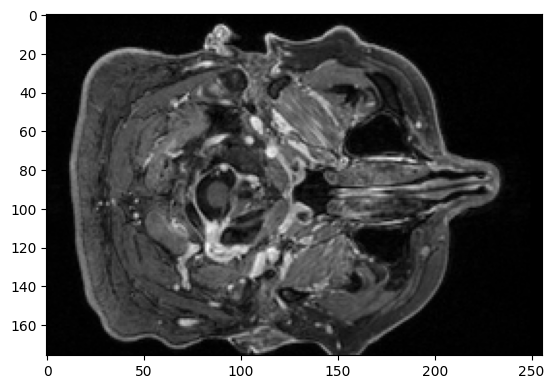

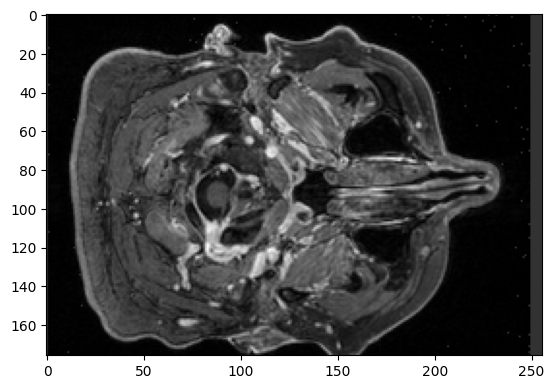

0.0


In [ ]:
import nibabel as nib
import skimage 
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, color, io
from skimage import segmentation
from skimage import morphology
from skimage.morphology import opening, closing

data = nib.load("../data/sub-KA02/anat/sub-KA02_run-02_T1w.nii.gz").get_fdata()
frame = data[:,:,89]
plt.imshow(frame,cmap='gray')
plt.show()

mascara = frame > 0
media = (frame[mascara]).mean()
desvio = (frame[mascara]).std()


frame_normalizado = (frame - media)/desvio
frame_normalizado = frame_normalizado*mascara

plt.imshow(frame_normalizado,cmap='gray')

plt.show()
print(frame_normalizado[~mascara].mean())







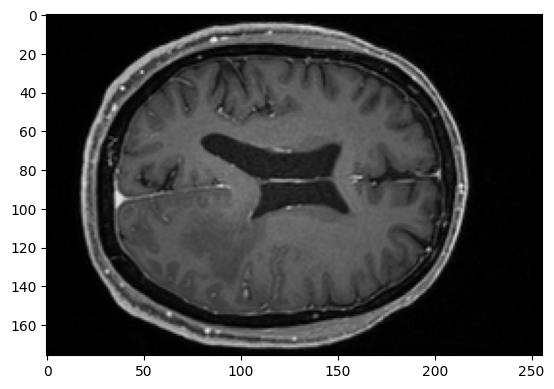

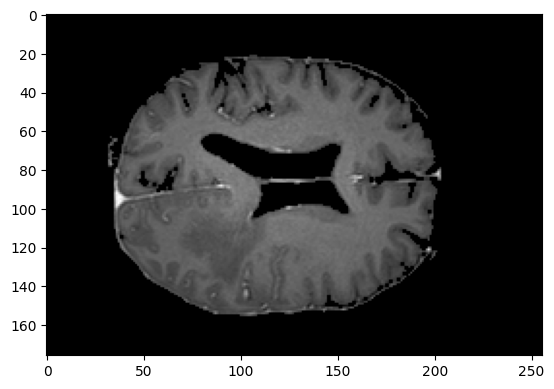

In [135]:
import nibabel as nib
import skimage 
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, color, io
from skimage import segmentation
from skimage import morphology
from skimage.morphology import opening, closing, disk, footprint_rectangle
from skimage.measure import label, regionprops

data = nib.load("../data/sub-KA02/anat/sub-KA02_run-02_T1w.nii.gz").get_fdata()

frame = data[:,:,174]
plt.imshow(frame,cmap='gray')
plt.show()
umbral = filters.threshold_otsu(frame)

imagen_binaria = frame > umbral

imagen_binaria = closing(imagen_binaria, footprint_rectangle((2,2)))
etiquetas = label(imagen_binaria, connectivity=2)
propiedades = regionprops(etiquetas)

areas = [region.area for region in propiedades]
indice = np.argmax(areas)
mascara = etiquetas == (indice + 1)

frame = frame * mascara

plt.imshow(frame,cmap='gray')
plt.show()


